In [ ]:
import os, random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.patches as patches, cv2
from ultralytics import YOLO


## Task 1 — Inspect the Dataset

In [9]:
data_dir = "data/DATA_CLEAN"
img_dir = os.path.join(data_dir, "images") if os.path.exists(os.path.join(data_dir, "images")) else data_dir
lbl_dir = os.path.join(data_dir, "labels") if os.path.exists(os.path.join(data_dir, "labels")) else data_dir

# Count files & Check matching
imgs = {os.path.splitext(f)[0]: f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
lbls = {os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.lower().endswith('.txt') and f != 'classes.txt'}

print(f"Total Images: {len(imgs)}\nTotal Labels: {len(lbls)}")
print(f"Images without labels: {len(imgs.keys() - lbls)}")
print(f"Labels without images: {len(lbls - imgs.keys())}\n")

# Class Distribution
class_counts = Counter()
for name in lbls:
    with open(os.path.join(lbl_dir, f"{name}.txt"), 'r') as f:
        for line in f:
            if line.strip(): class_counts[int(line.split()[0])] += 1

print("--- Class Distribution ---")
for cid, count in sorted(class_counts.items()):
    print(f"Class {cid}: {count} objects")

# Image Size Stats (100 random samples)
sampled_imgs = random.sample(list(imgs.values()), min(100, len(imgs)))
sizes = [Image.open(os.path.join(img_dir, f)).size for f in sampled_imgs]

df = pd.DataFrame(sizes, columns=['Width', 'Height'])
print("\n--- Image Size Statistics ---")
print(df.describe().loc[['min', 'max', 'mean']])

Total Images: 3442
Total Labels: 3442
Images without labels: 0
Labels without images: 0

--- Class Distribution ---
Class 0: 4029 objects

--- Image Size Statistics ---
        Width   Height
min    640.00   640.00
max   6000.00  4000.00
mean  2572.52  2000.45


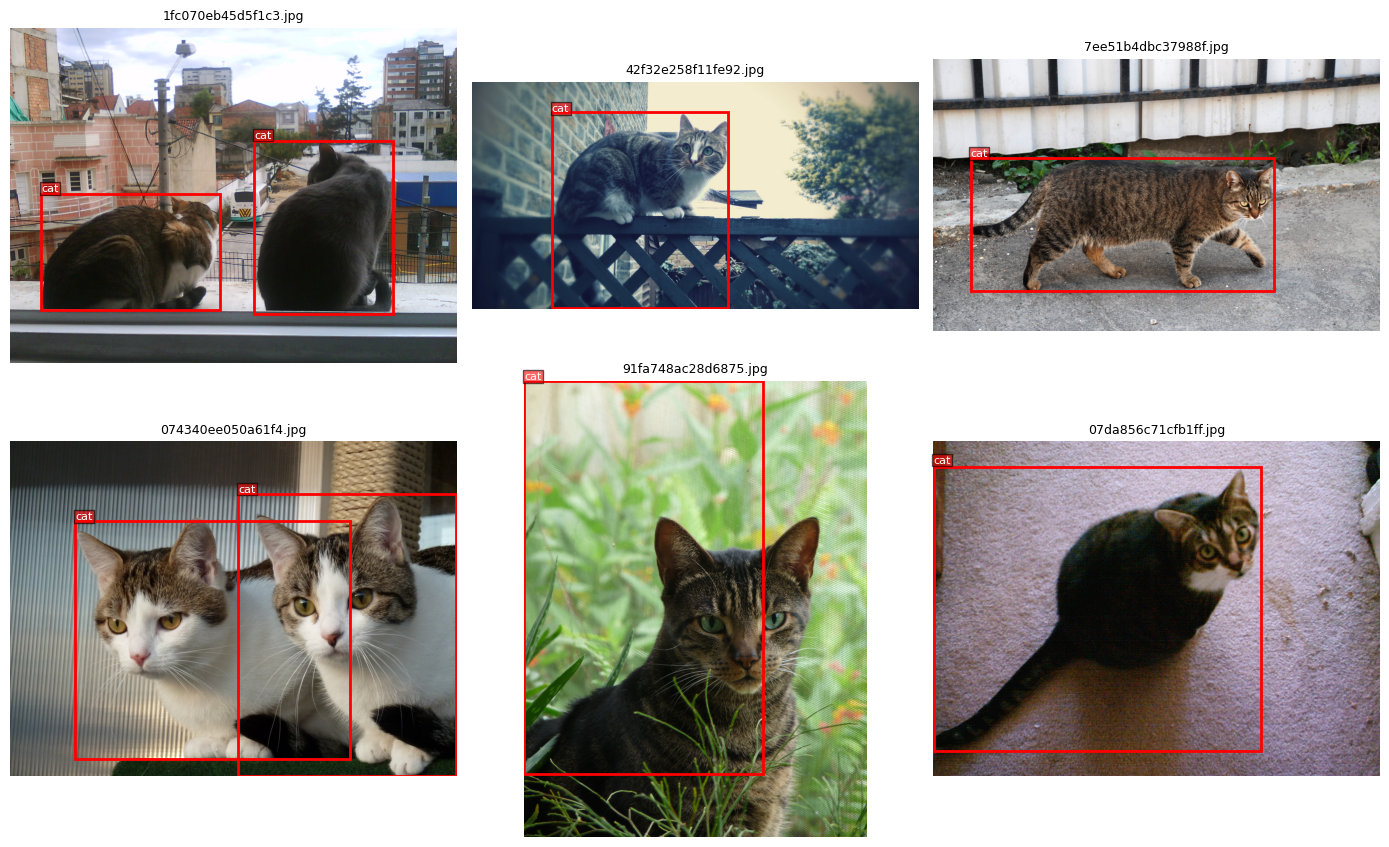

In [10]:
names = random.sample(list(imgs.keys()), 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for name, ax in zip(names, axes.ravel()):
    img = cv2.imread(os.path.join(img_dir, imgs[name]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape
    ax.imshow(img); ax.axis('off'); ax.set_title(imgs[name], fontsize=9)
    
    lbl_path = os.path.join(lbl_dir, f"{name}.txt")
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                cid, cx, cy, w, h = map(float, line.split())
                x = (cx - w/2) * w_img
                y = (cy - h/2) * h_img
                bw, bh = w * w_img, h * h_img
                
                ax.add_patch(patches.Rectangle((x, y), bw, bh, lw=2, ec='red', fc='none'))
                ax.text(x, y-10, "cat" if cid==0 else f"id:{int(cid)}", color='white', 
                        fontsize=8, bbox=dict(facecolor='red', alpha=0.6, pad=1))

plt.tight_layout(); plt.show()

## Task 2 — Build Train / Val / Test Splits

In [11]:
img_list = sorted(list(imgs.values()))
random.seed(42)
random.shuffle(img_list)

n_train = int(len(img_list) * 0.7)
n_val = int(len(img_list) * 0.15)

splits = {
    'train.txt': img_list[:n_train],
    'val.txt': img_list[n_train:n_train + n_val],
    'test.txt': img_list[n_train + n_val:]
}

for filename, files in splits.items():
    with open(os.path.join(data_dir, filename), 'w') as f:
        for name in files:
            sub_folder = "images/" if "images" in img_dir else ""
            f.write(f"DATA_CLEAN/{sub_folder}{name}\n")

print({k: len(v) for k, v in splits.items()})

yaml_content = """
path: ./data
train: DATA_CLEAN/train.txt
val: DATA_CLEAN/val.txt
test: DATA_CLEAN/test.txt
names:
  0: cat
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content.strip())

print("data.yaml created successfully!")

{'train.txt': 2409, 'val.txt': 516, 'test.txt': 517}
data.yaml created successfully!


## Task 3 — Pick a YOLO26 Variant and Train It

In [ ]:
model = YOLO("yolo26m.pt")

results = model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    device=0,
    project="cat_detection",
    name="yolo26m_run"
)

## Task 4 — Evaluate on the Test Set

In [ ]:
best_model = YOLO('cat_detection/yolo26m_run/weights/best.pt')

metrics = best_model.val(data="data.yaml", split="test")

results = metrics.results_dict

print("\n--- TEST SPLIT RESULTS ---")
print(f"mAP@0.5:0.95 : {results.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"mAP@0.5      : {results.get('metrics/mAP50(B)', 0):.4f}")
print(f"Precision (P): {results.get('metrics/precision(B)', 0):.4f}")
print(f"Recall (R)   : {results.get('metrics/recall(B)', 0):.4f}")

| Metric | Value |
|---|---|
| mAP@0.5 |  0.6906 |
| mAP@0.5:0.95 | 0.8954 |
| Mean precision | 0.8940 |
| Mean recall | 0.8435 |

### Evaluation Metrics Explanation

* **Precision (P):** Measures the accuracy of the model's positive predictions. It answers: *"Out of all the objects the model predicted as a cat, how many were actually cats?"* High precision means fewer false alarms.
* **Recall (R):** Measures the model's ability to find all the positive instances in the dataset. It answers: *"Out of all the actual cats present in the images, how many did the model manage to find?"* High recall means fewer missed objects.
* **mAP@0.5:** Mean Average Precision calculated at an Intersection over Union (IoU) threshold of 0.50. It measures the overall detection and classification performance, checking if the model successfully finds and correctly labels the objects with a loose, flexible boundary.
* **mAP@0.5:0.95:** The strictest metric, representing the average mAP calculated across multiple IoU thresholds ranging from 0.50 to 0.95 (with a step of 0.05). It evaluates how pixel-perfect and tight the predicted bounding boxes are around the objects.

## Task 5 — Visualise Predictions

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1. Modeli yüklə (Faylın yerli yaddaşda olduğu yer)
best_model = YOLO('cat_detection/yolo26m_run/weights/best.pt')

# 2. Test şəkillərini götür
test_images = splits['test.txt'][:6]

# 3. Vizualizasiyanı hazırla
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

print("Running inference on test images...")

for i, img_name in enumerate(test_images):
    # Yolun düzgünlüyü üçün (data_dir Task 1-də təyin olunub)
    img_path = os.path.join(data_dir, "images", os.path.basename(img_name.strip()))
    
    # Predict et
    results = best_model.predict(source=img_path, conf=0.25, verbose=False)[0]
    
    # Şəkli çək
    res_plotted = results.plot()
    res_rgb = Image.fromarray(res_plotted[..., ::-1])
    
    # Ekrana bas
    axes[i].imshow(res_rgb)
    axes[i].set_title(f"Image: {os.path.basename(img_path)}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()